## Bearbetning och kompensation av grundvattenniva

*E. Haaf (Chalmers), J. Altimiras Granel (COWI), 2026*

* Detta skript läser in grundvattenniva-matningar i absoluttryck [cmH20] och gor en barometrisk kompensation genom att subtrahera barotrycket.
* Om punkterna ligger nara varandra kan samma tidsserie for barometertryck användas.

Steg i detta skript:
1. Läser in två xlsx-filer, en med absoluttryck och en med barotryck. Skriptet forväntar sig tre kolumner i varje fil: datum och tid, samt kvalitetskontroll for varje värde med antingen Y for godkända värden eller N for bortsorterade värden. Därefter gör skriptet en barometrisk kompensation baserat på antagande av lasteffektiviten = 1.
2. Omvandlar värdena till masl.
3. Visualiserar kompenserad tidsserie
4. Samplar om data till dagliga värden 
5. Exporterar data

### 0. Importera Python bibliotek

In [1]:
# Bibliotek

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


### 1. Importera data

In [ ]:
# Hamta och sammanfoga data

# Avvikelser i tidssteg hanteras av funktionen merge_asof nedan
def obtain_data():
    
    # Be anvandaren ange filsokvagar
    p_baro_file = "../data/baro_abs_km.xlsx"
    p_absolute_file = "../data/head_abs_km.xlsx"
    
    # Las in data fran Excel-filerna
    # Las filerna, anvand kolumn 1, 2 och 3 och tilldela kolumnnamn
    p_baro_data = pd.read_excel(p_baro_file, usecols=[0, 1, 2], names=['Date/time', 'P_baro', 'Quality accepted?'])
    p_absolute_data = pd.read_excel(p_absolute_file, usecols=[0, 1, 2], names=['Date/time', 'P_absolute', 'Quality accepted?'])

    # Kvalitetskontroll
    # Filtrera bort rader dar 'Quality accepted?' ar 'N'
    # Kontrollerar varje rad om vardet ar Y. Om ja behålls det, annars inte
    p_baro_data = p_baro_data[p_baro_data['Quality accepted?'] == 'Y']
    p_absolute_data = p_absolute_data[p_absolute_data['Quality accepted?'] == 'Y']
    
    # Sakerstall att DateTime-kolumnerna har korrekt format
    # Konverterar den forsta kolumnen till datetime enligt pandas
    p_baro_data['Date/time'] = pd.to_datetime(p_baro_data['Date/time'])
    p_absolute_data['Date/time'] = pd.to_datetime(p_absolute_data['Date/time'])

    # Sammanfoga dataseten pa DateTime-kolumnen med en tolerans, tar närmaste värde om exakt match saknas
    # Toleransen är mycket viktig eftersom vissa väarden kan tas bort i filtreringsprocessen
    # Om merge_asof inte hittar nagot inom toleransen lamnas NaN pa den platsen, vilket syns senare
    merged_data = pd.merge_asof(p_baro_data.sort_values('Date/time'), 
                                p_absolute_data.sort_values('Date/time'), 
                                on='Date/time', 
                                tolerance=pd.Timedelta('2 hours'),
                                direction='nearest')

    return merged_data, p_absolute_file

merged_data, p_absolute_file = obtain_data()

# Beräkna kompenserat tryck och lägg till det i DataFrame
merged_data['P_compensated'] = merged_data['P_absolute'] - merged_data['P_baro']

merged_data['P_compensated'] = merged_data['P_compensated'].round(3)

merged_data

,Date/time,P_baro,Quality accepted?_x,P_absolute,Quality accepted?_y,P_compensated
0,2022-12-07 12:00:00,1020.550,Y,NaN,NaN,NaN
1,2022-12-07 15:00:00,1017.300,Y,1393.533000,Y,376.233
2,2022-12-07 18:00:00,1016.225,Y,1393.008000,Y,376.783
3,2022-12-07 21:00:00,1015.500,Y,1392.075000,Y,376.575
4,2022-12-08 00:00:00,1014.925,Y,1391.550000,Y,376.625
...,...,...,...,...,...,...
6437,2025-02-19 03:00:00,1041.300,Y,1502.208333,Y,460.908
6438,2025-02-19 06:00:00,1041.725,Y,1503.025000,Y,461.300
6439,2025-02-19 09:00:00,1043.275,Y,1503.258333,Y,459.983
6440,2025-02-19 12:00:00,1042.950,Y,1503.550000,Y,460.600


### 2. Omvandla data till masl.

In [3]:
# Referensniva i meter over havet vid brunnens topp (detta värde ändras för varje objekt)
reference_level = 75.86

# Avstand fran brunnens topp till nedsankt givare (detta värde ändras för varje objekt)
diver_distance = 15.55

# Berakna givarens niva
diver_level = reference_level - diver_distance

# Rakna om kompenserad serie till masl.
merged_data['h_compensated'] = merged_data['P_compensated'] / 100 + diver_level


### 3. Visualisera resultaten

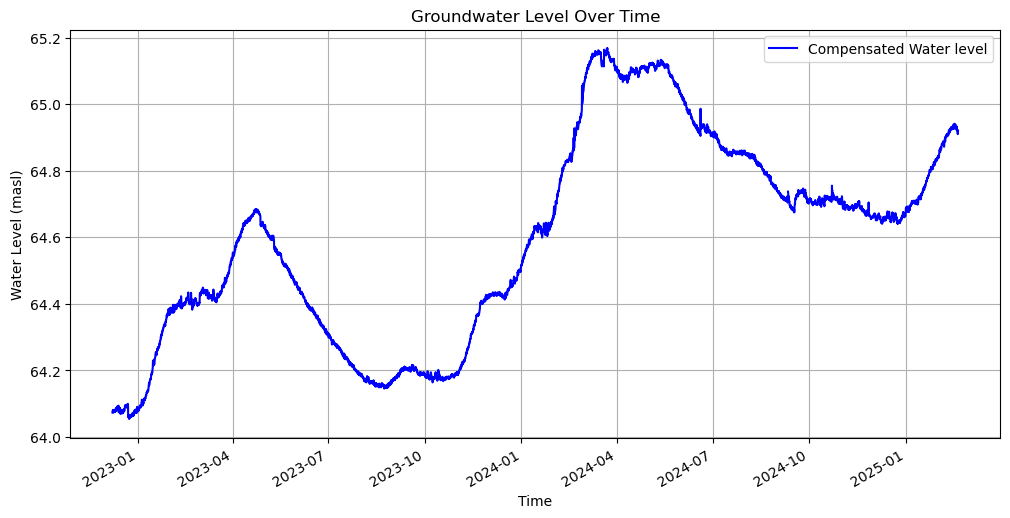

In [4]:

# Skapa figur
plt.figure(figsize=(12, 6))

# Plotta kompenserad vattenniva
plt.plot(merged_data['Date/time'], merged_data['h_compensated'], label='Compensated Water level', color='blue', linestyle='-')

# Lagg till titel och axelrubriker
plt.title('Groundwater Level Over Time')
plt.xlabel('Time')
plt.ylabel('Water Level (masl)')
plt.legend()

# Forbattra formatering av datum pa x-axeln
plt.gcf().autofmt_xdate()  # Formaterar datumetiketter automatiskt for battre lasbarhet
plt.grid(True)  # Lagg till rutnat for battre lasbarhet

# Visa figur
plt.show()

### 4. Sampla om till dagliga medelvarden

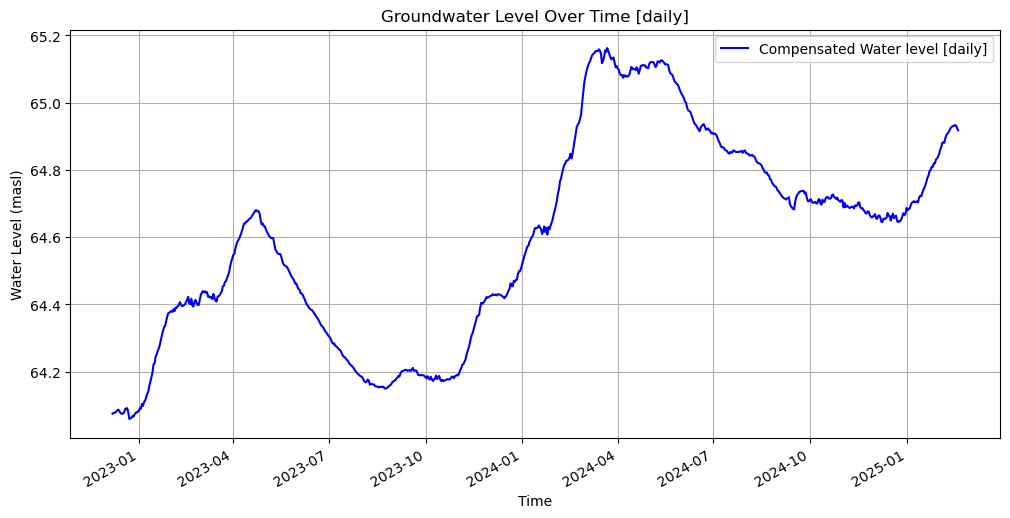

In [5]:
# Skapa en ny dataframe med kolumn 0 och 6
daily_avg = merged_data.iloc[:, [0, 6]].copy()

# Satt datumkolumnen som index
daily_avg.set_index(daily_avg.columns[0], inplace=True)

# Sampla om till dagligt medelvarde
daily_avg = daily_avg.resample('D').mean()

# Aterstall index
daily_avg = daily_avg.reset_index()

# Visualisera omsamplade data
# Skapa figur
plt.figure(figsize=(12, 6))

# Plotta kompenserad vattenniva
plt.plot(daily_avg['Date/time'], daily_avg['h_compensated'], label='Compensated Water level [daily]', color='blue', linestyle='-')

# Lagg till titel och axelrubriker
plt.title('Groundwater Level Over Time [daily]')
plt.xlabel('Time')
plt.ylabel('Water Level (masl)')
plt.legend()

# Forbattra formatering av datum pa x-axeln
plt.gcf().autofmt_xdate()  # Formaterar datumetiketter automatiskt for battre lasbarhet
plt.grid(True)  # Lagg till rutnat for battre lasbarhet

# Visa figur
plt.show()

### 5. Exportera resultat

In [7]:
# Funktion for att exportera data

def export_result(dataframe):
    # Ange namnet pa originalfilen
    original_water_file = p_absolute_file

    # Lat anvandaren ange utdatakatalog
    #compensated_dir = input("Enter the directory where you want to save the file: ")
    #if not os.path.exists(compensated_dir):
    #    os.makedirs(compensated_dir, exist_ok=True)

    # Ange katalog dar filen ska sparas
    compensated_dir = "../data"
    if not os.path.exists(compensated_dir):
        os.makedirs(compensated_dir, exist_ok=True)

    # Skapa filsokvagen for den nya Excel-filen
    base_file_name = os.path.splitext(os.path.basename(original_water_file))[0]
    new_file_name = base_file_name + '_compensated_daily' + '.xlsx'
    file_path = os.path.join(compensated_dir, new_file_name)

    # Exportera DataFrame till Excel
    try:
        dataframe.to_excel(file_path, index=False)
        print(f"Data successfully exported to {file_path}")
    except Exception as e:
        print(f"Error exporting data: {e}")

#export_result(merged_data)
export_result(daily_avg)
#export_result(weekly_avg)

Data successfully exported to ../data\head_abs_km_compensated_daily.xlsx
